##Chung Vong (Simon) - Gabriel Veneziani - Maria Marquelio - Eduardo Carreno

#Final Project

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as style
import plotly.express as px

##**Part 1: Data Exploration (Using pandas)**

Perform initial exploration:

• Display first 5 rows

• Dataset shape (rows, columns)

• Column names

• Data types

• Summary statistics using: df.describe()

• Count of missing values per column: df.isnull().sum()

• Percentage of missing values per column

• Value counts for at least 2 categorical columns



In [ ]:
df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [ ]:
df.shape

(344, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [ ]:
df.dtypes

,0
species,object
island,object
bill_length_mm,float64
bill_depth_mm,float64
flipper_length_mm,float64
body_mass_g,float64
sex,object


In [ ]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [ ]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [ ]:
valorf = df.isnull().sum()
tc = np.prod(df.shape)
tm = valorf.sum()
print((tm/tc)*100, "%")

0.7890365448504983 %


In [ ]:
print(df["sex"].value_counts())

sex
Male      168
Female    165
Name: count, dtype: int64


In [ ]:
print(df["species"].value_counts())

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


##**Part 2: Data Cleaning**

If missing values exist:

• For numerical columns → replace with median

• For categorical columns → replace with mode

Show the code and explain.

You may:

• Create at least 1–2 new derived columns

• Convert data types if necessary

In [ ]:
dfnew = df.fillna({"bill_length_mm": df["bill_length_mm"].mean()})

In [ ]:
dfnew = dfnew.fillna({"bill_depth_mm": df["bill_depth_mm"].mean()})

In [ ]:
dfnew = dfnew.fillna({"flipper_length_mm": df["flipper_length_mm"].mean()})

In [ ]:
dfnew = dfnew.fillna({"body_mass_g": df["body_mass_g"].mean()})

In [ ]:
dfnew = dfnew.fillna({"sex": df["sex"].mode()[0]})

In [ ]:
dfnew.isnull().sum()

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [ ]:
dfnew.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,Female
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,Male
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,Female


In [ ]:
dfnew['bill_ratio'] = dfnew['bill_length_mm'] / dfnew["bill_depth_mm"]
dfnew.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_ratio
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,Male,2.090909
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,Female,2.270115
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,Female,2.238889
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,Male,2.560871
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,Female,1.901554


In [ ]:
dfnew['body_mass_mlg'] = dfnew['body_mass_g'] * 1000
dfnew.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_ratio,body_mass_mlg
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,Male,2.090909,3.750000e+06
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,Female,2.270115,3.800000e+06
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,Female,2.238889,3.250000e+06
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,Male,2.560871,4.201754e+06
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,Female,1.901554,3.450000e+06


In [ ]:
dfnew['body_mass_kg'] = dfnew['body_mass_g'] / 1000
dfnew.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_ratio,body_mass_mlg,body_mass_kg
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,Male,2.090909,3.750000e+06,3.750000
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,Female,2.270115,3.800000e+06,3.800000
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,Female,2.238889,3.250000e+06,3.250000
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,Male,2.560871,4.201754e+06,4.201754
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,Female,1.901554,3.450000e+06,3.450000


##**Part 3: Data Visualization (Using Matplotlib ONLY)**

You must create at least 5 different visualizations.

Examples:

• Line plot

• Bar chart

• Histogram

• Scatter plot

• Box plot

• Pie chart (if appropriate)

Each visualization must:

• Have a clear title

• Have labeled axes

• Use appropriate formatting

• Be readable and professional

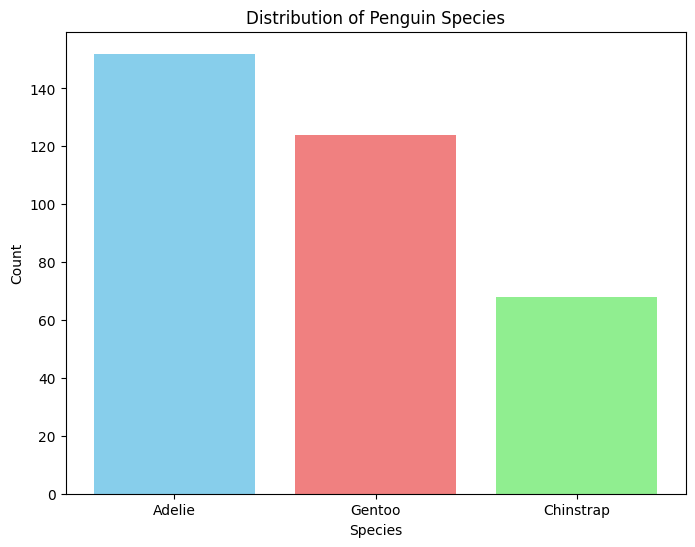

In [ ]:
species_counts = dfnew['species'].value_counts()
plt.figure(figsize=(8, 6))
plt.bar(species_counts.index, species_counts.values, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Distribution of Penguin Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

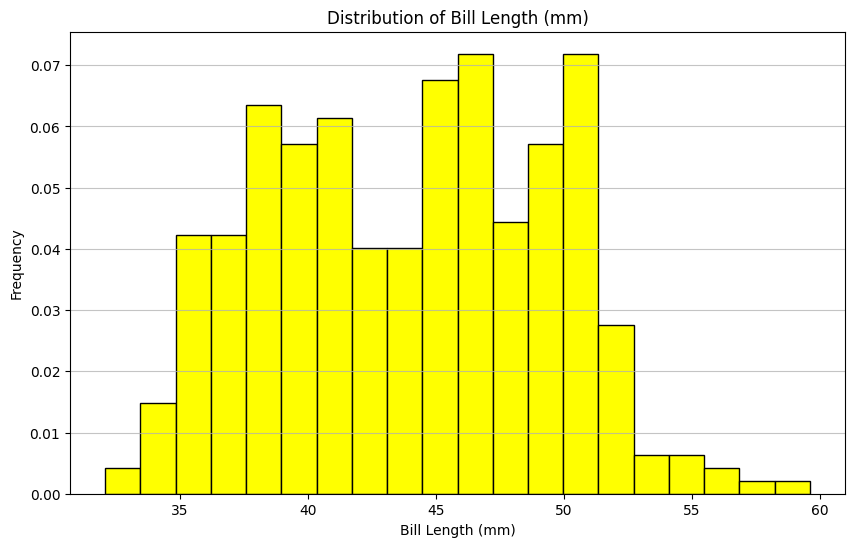

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(dfnew['bill_length_mm'], bins=20, color='yellow', edgecolor='black', density=True)
plt.title('Distribution of Bill Length (mm)')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

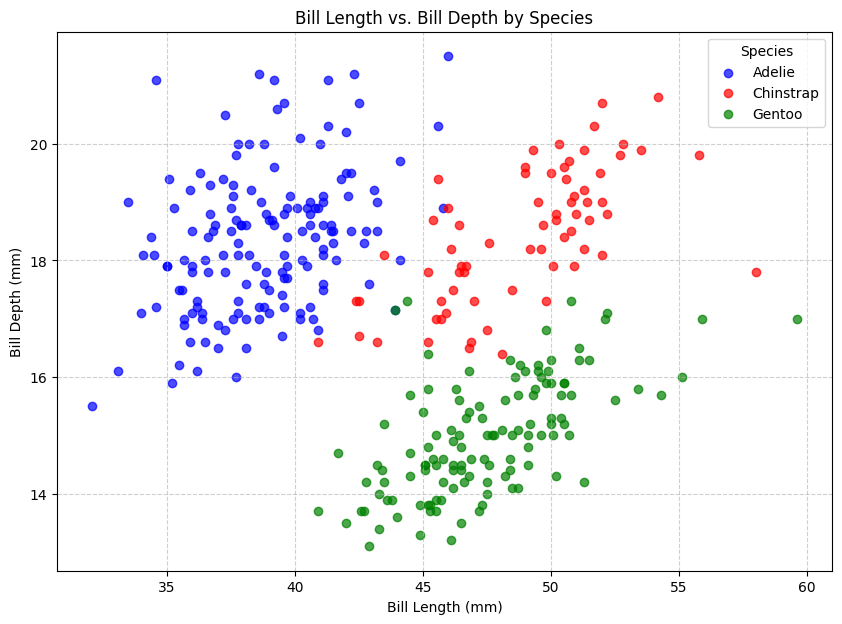

In [ ]:
plt.figure(figsize=(10, 7))
species_names = dfnew['species'].unique()
colors = ['blue', 'red', 'green'] # Define colors for each species

for i, species in enumerate(species_names):
    species_data = dfnew[dfnew['species'] == species]
    plt.scatter(species_data['bill_length_mm'], species_data['bill_depth_mm'],
                label=species, color=colors[i], alpha=0.7)

plt.title('Bill Length vs. Bill Depth by Species')
plt.xlabel('Bill Length (mm)')
plt.ylabel('Bill Depth (mm)')
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/tmp/ipython-input-531/1978306623.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(bill_ratio_data, labels=species_names)


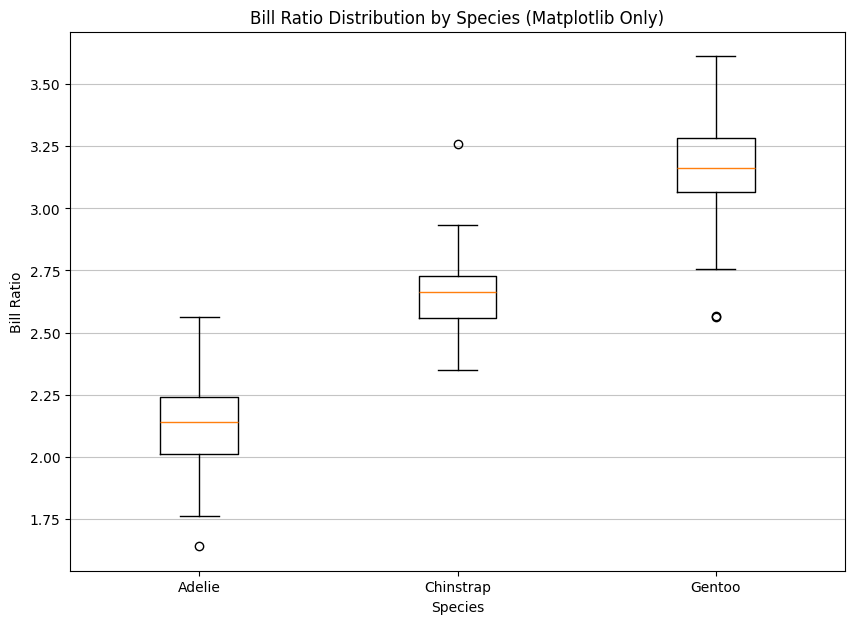

In [ ]:
bill_ratio_data = [dfnew[dfnew['species'] == s]['bill_ratio'] for s in species_names]
plt.figure(figsize=(10, 7))
plt.boxplot(bill_ratio_data, labels=species_names)
plt.title('Bill Ratio Distribution by Species (Matplotlib Only)')
plt.xlabel('Species')
plt.ylabel('Bill Ratio')
plt.grid(axis='y', alpha=0.75)
plt.show()

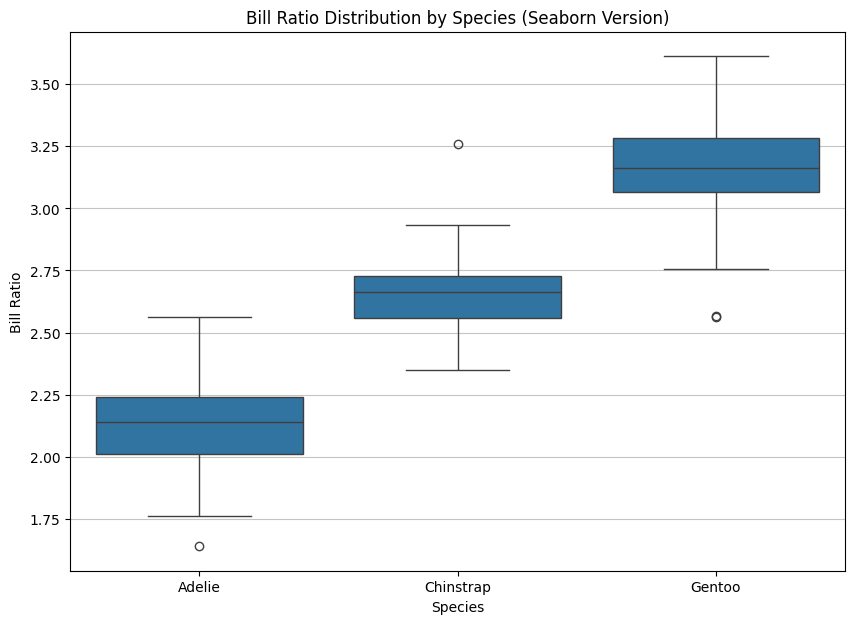

In [ ]:
plt.figure(figsize=(10, 7))
sns.boxplot(x='species', y='bill_ratio', data=dfnew)
plt.title('Bill Ratio Distribution by Species (Seaborn Version)')
plt.xlabel('Species')
plt.ylabel('Bill Ratio')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
species_by_island = dfnew.groupby(['island', 'species']).size().reset_index(name='count')
species_by_island_df = pd.DataFrame(species_by_island)
print(species_by_island_df)


      island    species  count
0     Biscoe     Adelie     44
1     Biscoe     Gentoo    124
2      Dream     Adelie     56
3      Dream  Chinstrap     68
4  Torgersen     Adelie     52


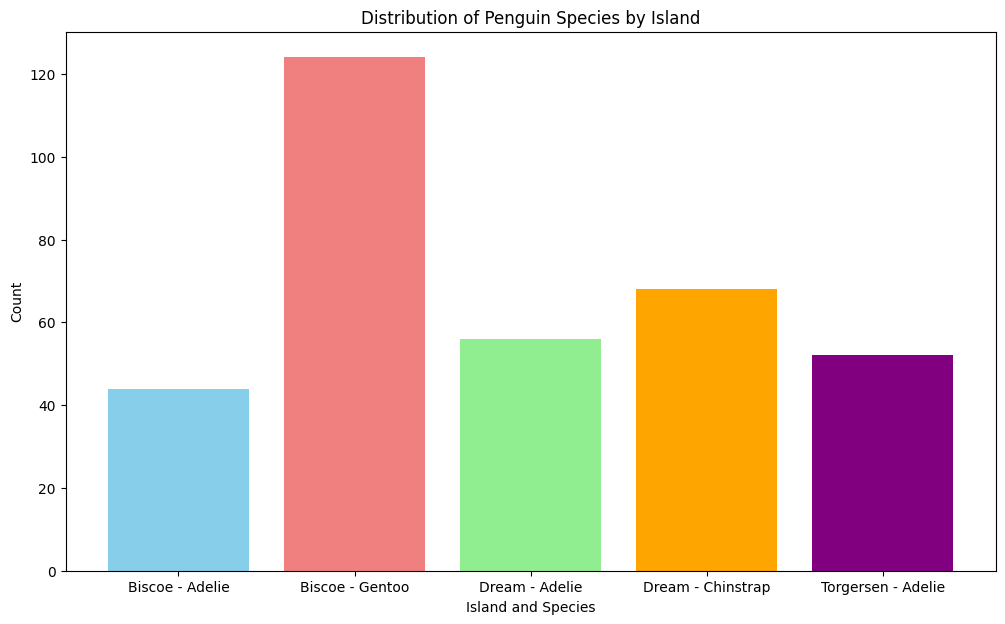

In [ ]:
plt.figure(figsize=(12, 7))
bar_labels = [f"{row['island']} - {row['species']}" for index, row in species_by_island_df.iterrows()]
plt.bar(bar_labels, species_by_island_df['count'], color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple'])
plt.title('Distribution of Penguin Species by Island')
plt.xlabel('Island and Species')
plt.ylabel('Count')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

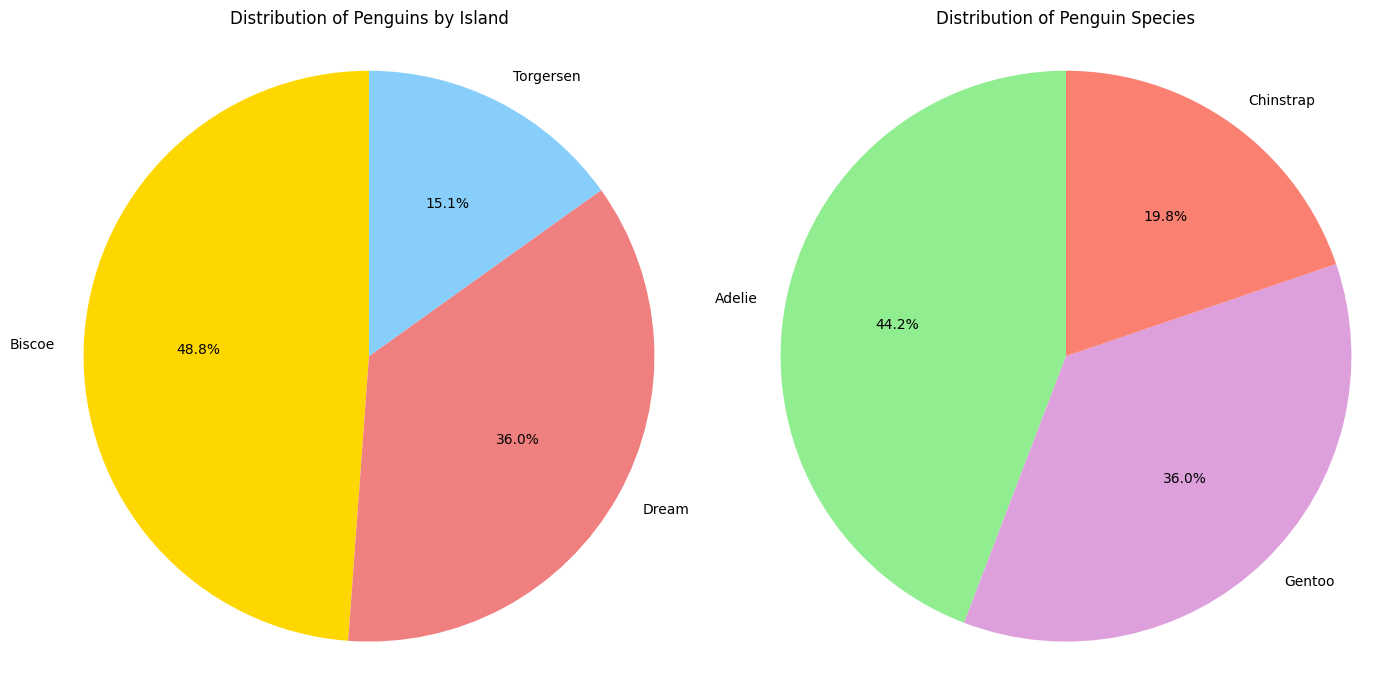

In [ ]:
island_counts = dfnew['island'].value_counts()
species_counts = dfnew['species'].value_counts()
plt.figure(figsize=(14, 7))

# Pie chart for 'island' distribution
plt.subplot(1, 2, 1) # 1 row, 2 columns, first subplot
plt.pie(island_counts, labels=island_counts.index, autopct='%1.1f%%', startangle=90, colors=['gold', 'lightcoral', 'lightskyblue'])
plt.title('Distribution of Penguins by Island')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# Pie chart for 'species' distribution
plt.subplot(1, 2, 2) # 1 row, 2 columns, second subplot
plt.pie(species_counts, labels=species_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'plum', 'salmon'])
plt.title('Distribution of Penguin Species')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()